### QED-C Application-Oriented Benchmarks - Pre-defined Equal1-Runner

Using Qiskit to construct and run benchmarks, but inserting in Equal1 way of executing. 

## Default configurations
Change the following values to control benchmark parameters

In [1]:
# Generic becnhmark paramters
min_qubits = 2
max_qubits = 17
skip_qubits = 1
max_circuits = 2
num_shots = 1000

# Equal1 device specific
equal1_device = "equal1_simulator"
equal1_noise_model = "bell2-17-gen-preview"

Setup equal1 execution environment

In [2]:
import base64

from qbraid import QbraidProvider
from qiskit import QuantumCircuit, qasm3


class QBraidBackEnd():
    def __init__(self):
        self.name = "QBraidEqual1Backend"

class QBraidResult:
    def __init__(self, counts, exec_time, transpiled_circuit_metrics):
        self.exec_time = exec_time
        self.counts = counts
        self.transpiled_circuit_metrics = transpiled_circuit_metrics

    def get_counts(self, qc):
        return self.counts

    def get_transpiled_circuit_metrics(self):
        return self.transpiled_circuit_metrics

class QBraidExecutor():
    def __init__(self):
        provider = QbraidProvider()
        self.device = provider.get_device("equal1_simulator")

    def __call__(self, qc : QuantumCircuit, backend_name : str, backend, shots, **kwargs) -> QBraidResult:
        # print(f"attempting to run {qc} on {backend_name}, on {backend} with {shots} and {kwargs}")

        runtime_options = {
            "simulation_platform": "GPU",
            "execution_options": {"optimization_level": 2},
        }

        backend = "StateVector" if qc.num_qubits > 8 else "DensityMatrix"

        job = self.device.run(qc, shots=shots, noise_model="bell2-17-gen-preview", runtime_options=runtime_options, backend=backend)
        job.wait_for_final_state()  # Wait for the job to complete and get final state

        if job.status().name != "COMPLETED":
            job_result = job.client.get_job_results(job.id)
            print(f"\n@@@@@@@@@@@@@@ \n JOB FAILED for {qc} \n With error message:\n {job_result['statusText']}\n @@@@@@@@@@@@@@@@@@ \n ")


        result = job.result()
        counts = result.data.get_counts()
        # print(counts)

        result_json = job.client.get_job_results(job.id)
        inner_exec_time = result_json['executionMetrics']['executor']


        transpiled_circuit = base64.b64decode(result_json['compiledOutput']).decode('utf-8')
        transpiled_qc = qasm3.loads(transpiled_circuit)

        from _common.qiskit.execute import get_circuit_metrics
        metrics = get_circuit_metrics(transpiled_qc)


        return QBraidResult(counts, inner_exec_time, metrics)



In [3]:
# Common setup parameters
backend_id = "qasm_simulator"

hub = ""
group = ""
project = ""
provider_backend = None

exec_options = {
    "executor" : QBraidExecutor()
}


/home/ubuntu/work/QC-App-Oriented-Benchmarks/.venv/lib/python3.12/site-packages/qbraid_core/_compat.py:44: UserWarning: You are using qbraid-core version 0.1.41, however, version 0.2.0 is available. To avoid compatibility issues, consider upgrading.
  warnings.warn(
/home/ubuntu/work/QC-App-Oriented-Benchmarks/.venv/lib/python3.12/site-packages/qbraid/runtime/native/provider.py:151: RuntimeWarning: The default runtime configuration for device 'equal1_simulator' includes transpilation to program type 'cudaq', which is not registered.
  warnings.warn(


### Deutsch-Jozsa

Deutsch-Jozsa Benchmark Program - Qiskit
... execution starting at Feb 26, 2026 10:03:50 UTC
************
Executing [2] circuits with num_qubits = 3
************
Executing [2] circuits with num_qubits = 4
************
Average Circuit Algorithmic Depth, ξ (xi) for the 3 qubit group = 7, 0.083
Average Normalized Transpiled Depth, ξ (xi), 2q gates for the 3 qubit group = 12, 0.037, 1.0
Average Creation, Elapsed, Execution Time for the 3 qubit group = 0.001, 13.178, 0.085 secs
Average Hellinger, Normalized Fidelity for the 3 qubit group = 0.946, 0.928

************
Executing [2] circuits with num_qubits = 5
************
Executing [2] circuits with num_qubits = 6
************
Average Circuit Algorithmic Depth, ξ (xi) for the 4 qubit group = 8, 0.088
Average Normalized Transpiled Depth, ξ (xi), 2q gates for the 4 qubit group = 12, 0.042, 1.5
Average Creation, Elapsed, Execution Time for the 4 qubit group = 0.0, 23.762, 0.101 secs
Average Hellinger, Normalized Fidelity for the 4 qubit group =

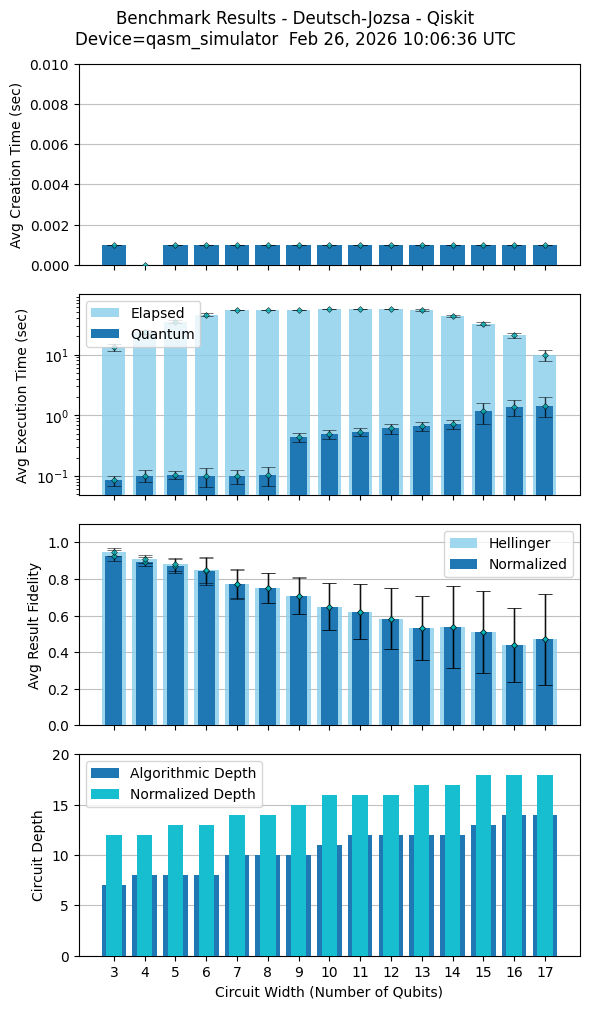

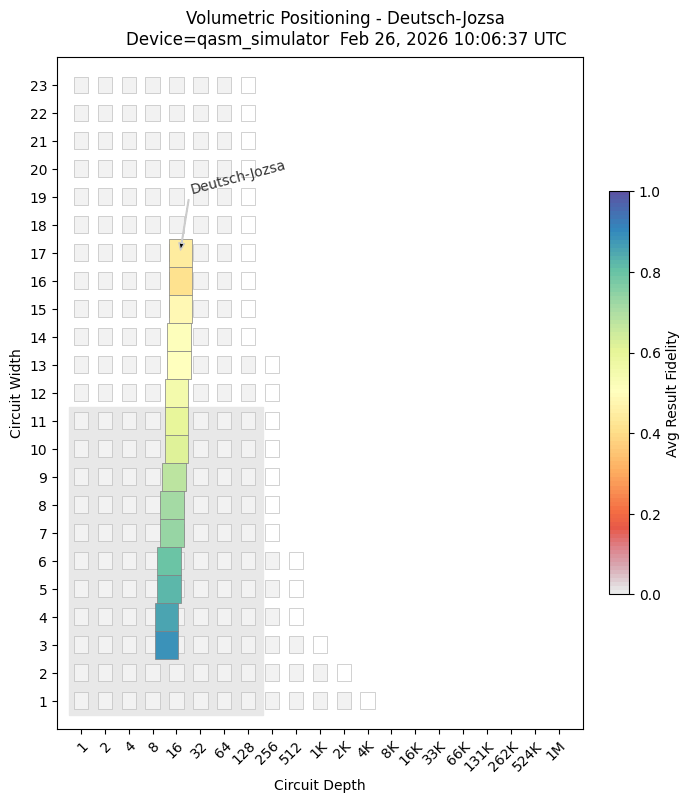

In [4]:
import sys
sys.path.insert(1, "deutsch-jozsa/qiskit")
import dj_benchmark
dj_benchmark.run(min_qubits=min_qubits, max_qubits=max_qubits, skip_qubits=skip_qubits,
                max_circuits=max_circuits, num_shots=num_shots,
                backend_id=backend_id, provider_backend=provider_backend,
                hub=hub, group=group, project=project, exec_options=exec_options)

### Bernstein-Vazirani - Method 1

Bernstein-Vazirani (1) Benchmark Program - Qiskit
... execution starting at Feb 26, 2026 10:06:39 UTC
************
Executing [2] circuits with num_qubits = 3
************
Executing [2] circuits with num_qubits = 4
************
Average Circuit Algorithmic Depth, ξ (xi) for the 3 qubit group = 6, 0.111
Average Normalized Transpiled Depth, ξ (xi), 2q gates for the 3 qubit group = 13, 0.042, 1.0
Average Creation, Elapsed, Execution Time for the 3 qubit group = 0.002, 13.179, 0.078 secs
Average Hellinger, Normalized Fidelity for the 3 qubit group = 0.962, 0.949

************
Executing [2] circuits with num_qubits = 5
************
Executing [2] circuits with num_qubits = 6
************
Average Circuit Algorithmic Depth, ξ (xi) for the 4 qubit group = 6, 0.129
Average Normalized Transpiled Depth, ξ (xi), 2q gates for the 4 qubit group = 14, 0.049, 1.5
Average Creation, Elapsed, Execution Time for the 4 qubit group = 0.002, 23.838, 0.079 secs
Average Hellinger, Normalized Fidelity for the 4 qu

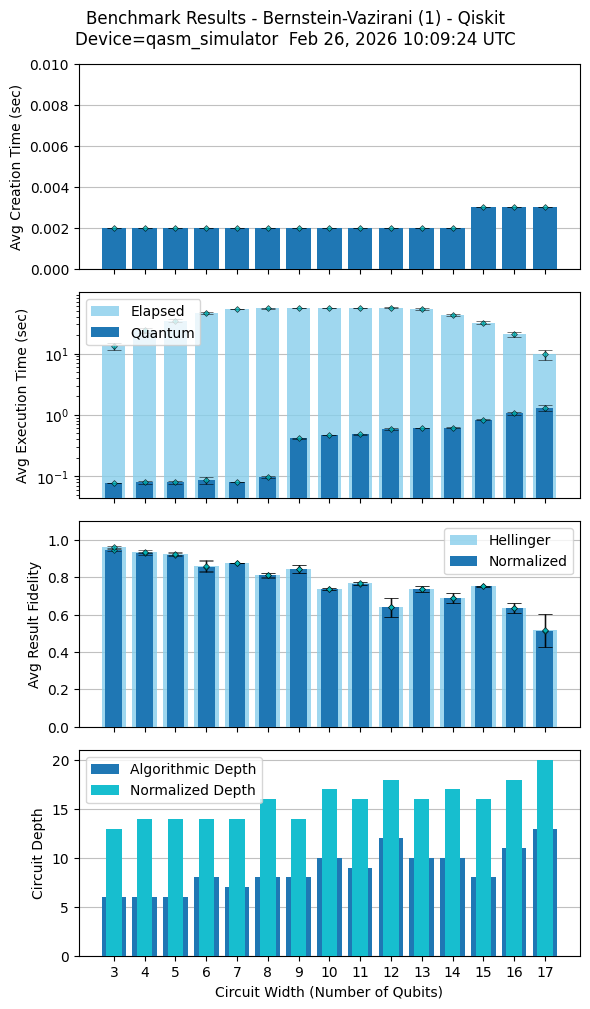

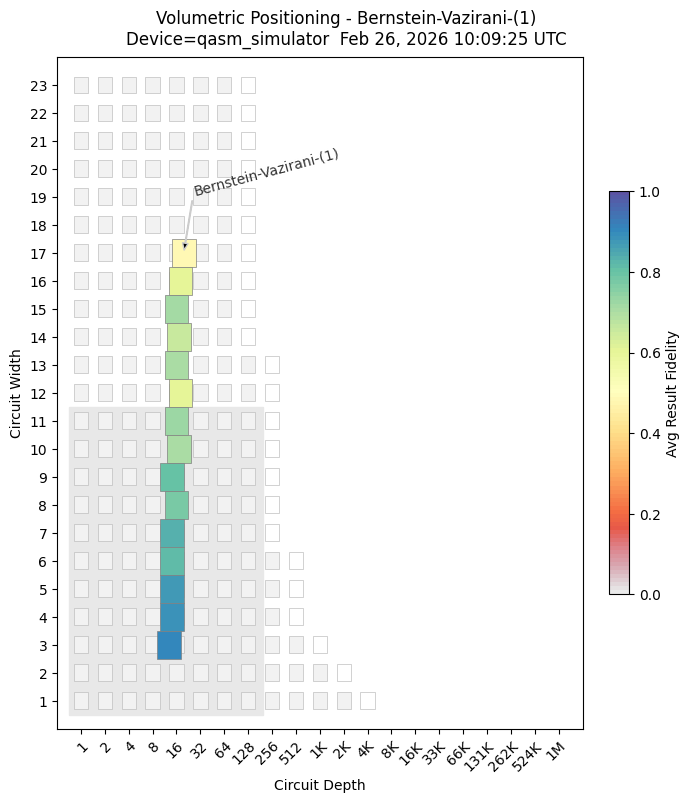

In [5]:
import sys
sys.path.insert(1, "bernstein-vazirani")
import bv_benchmark
bv_benchmark.run(min_qubits=min_qubits, max_qubits=max_qubits, skip_qubits=skip_qubits,
                max_circuits=max_circuits, num_shots=num_shots,
                method=1,
                backend_id=backend_id, provider_backend=provider_backend,
                hub=hub, group=group, project=project, exec_options=exec_options)

### Hidden Shift

Hidden Shift Benchmark Program - Qiskit
... execution starting at Feb 26, 2026 10:09:27 UTC
************
Executing [2] circuits with num_qubits = 2
************
Executing [2] circuits with num_qubits = 4
************
Average Circuit Algorithmic Depth, ξ (xi) for the 2 qubit group = 8, 0.2
Average Normalized Transpiled Depth, ξ (xi), 2q gates for the 2 qubit group = 14, 0.091, 2.0
Average Creation, Elapsed, Execution Time for the 2 qubit group = 0.002, 103.807, 0.106 secs
Average Hellinger, Normalized Fidelity for the 2 qubit group = 0.927, 0.903

************
Executing [2] circuits with num_qubits = 6
************
Executing [2] circuits with num_qubits = 8
************
Average Circuit Algorithmic Depth, ξ (xi) for the 4 qubit group = 8, 0.211
Average Normalized Transpiled Depth, ξ (xi), 2q gates for the 4 qubit group = 14, 0.093, 4.0
Average Creation, Elapsed, Execution Time for the 4 qubit group = 0.002, 24.218, 0.118 secs
Average Hellinger, Normalized Fidelity for the 4 qubit group =

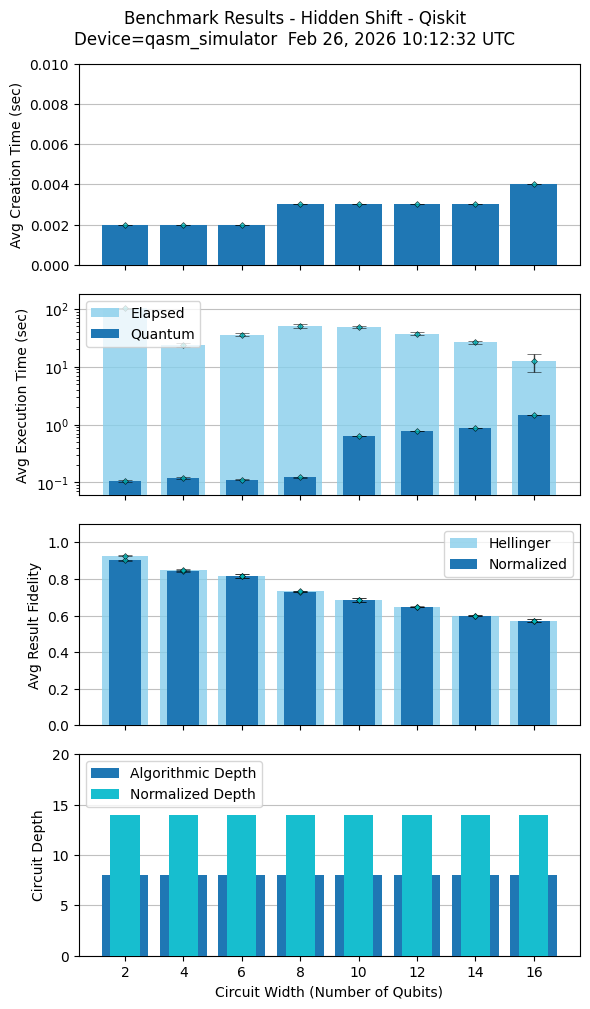

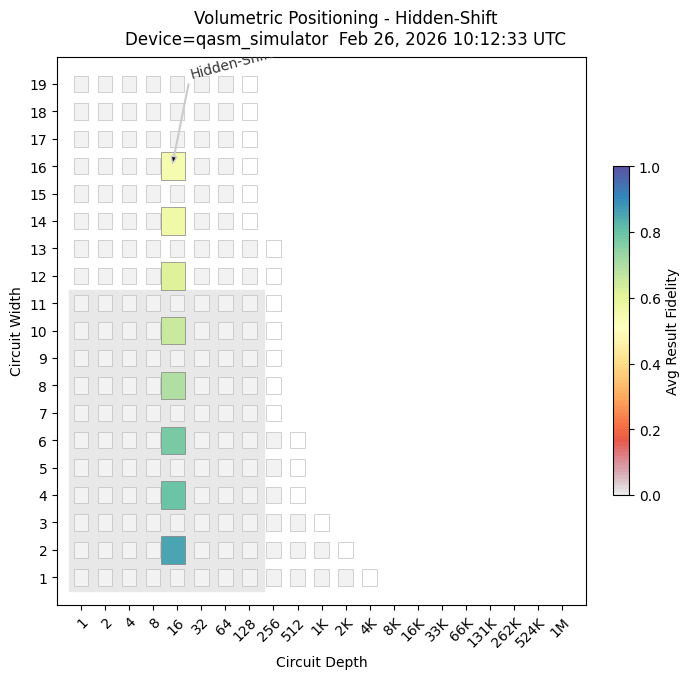

In [6]:
import sys
sys.path.insert(1, "hidden-shift")
import hs_benchmark
hs_benchmark.run(min_qubits=min_qubits, max_qubits=max_qubits,
                max_circuits=max_circuits, num_shots=num_shots,
                backend_id=backend_id, provider_backend=provider_backend,
                hub=hub, group=group, project=project, exec_options=exec_options)

### Grover

Grover's Search Benchmark Program - Qiskit
... execution starting at Feb 26, 2026 10:12:35 UTC
************
Executing [2] circuits with num_qubits = 8
************
Average Circuit Algorithmic Depth, ξ (xi) for the 8 qubit group = 134, 0.04
Average Normalized Transpiled Depth, ξ (xi), 2q gates for the 8 qubit group = 16048, 0.237, 5280.0
Average Creation, Elapsed, Execution Time for the 8 qubit group = 0.018, 440.494, 134.181 secs
Average Hellinger, Normalized Fidelity for the 8 qubit group = 0.006, 0.001

... execution complete at Feb 26, 2026 10:22:14 UTC in 579.438 secs

Sample Circuit:
        ┌───┐ ░ ┌─────────┐┌───────────┐ ░ ┌─────────┐┌───────────┐ ░ »
q138_0: ┤ H ├─░─┤0        ├┤0          ├─░─┤0        ├┤0          ├─░─»
        ├───┤ ░ │         ││           │ ░ │         ││           │ ░ »
q138_1: ┤ H ├─░─┤1        ├┤1          ├─░─┤1        ├┤1          ├─░─»
        ├───┤ ░ │         ││           │ ░ │         ││           │ ░ »
q138_2: ┤ H ├─░─┤2        ├┤2          ├─░─┤

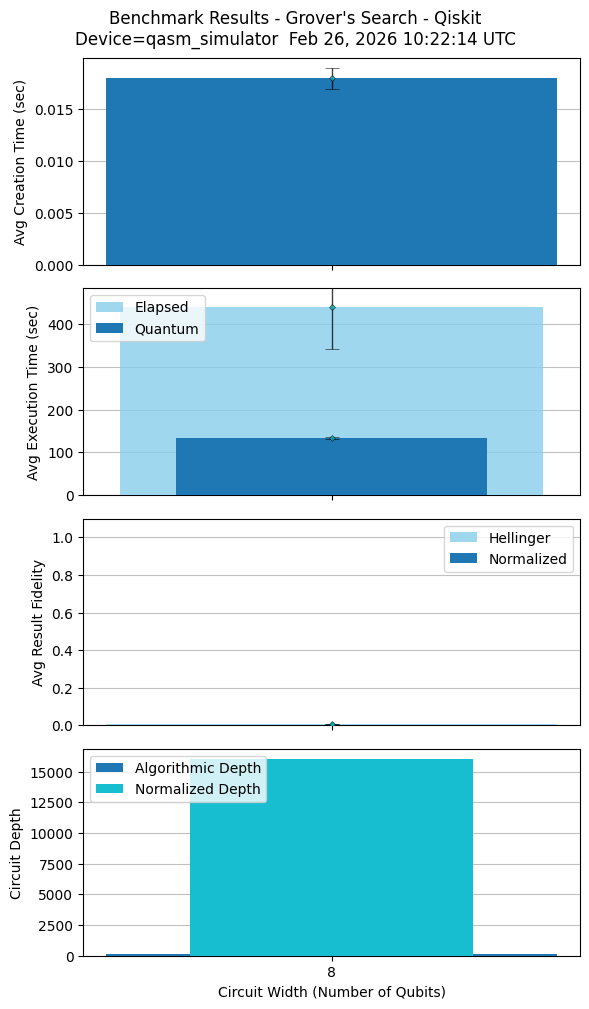

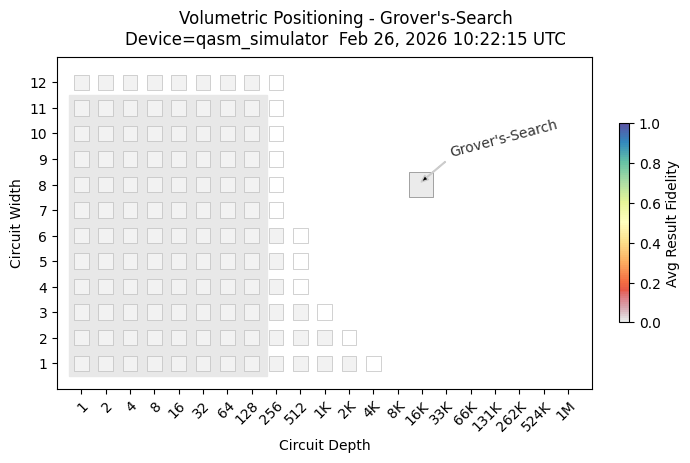

In [7]:
import sys
sys.path.insert(1, "grovers/qiskit")
import grovers_benchmark

grover_max_circuits = 8 if max_circuits > 8 else max_circuits
grovers_benchmark.run(min_qubits=8, max_qubits=8, skip_qubits=skip_qubits,
                max_circuits=grover_max_circuits, num_shots=num_shots,
                backend_id=backend_id, provider_backend=provider_backend,
                hub=hub, group=group, project=project, exec_options=exec_options)

### Phase Estimation

Phase Estimation Benchmark Program - Qiskit
... execution starting at Feb 26, 2026 10:22:16 UTC
************
Executing [2] circuits with num_qubits = 3
************
Executing [2] circuits with num_qubits = 4
************
Average Circuit Algorithmic Depth, ξ (xi) for the 3 qubit group = 16, 0.316
Average Normalized Transpiled Depth, ξ (xi), 2q gates for the 3 qubit group = 34, 0.142, 6.0
Average Creation, Elapsed, Execution Time for the 3 qubit group = 0.009, 13.297, 0.226 secs
Average Hellinger, Normalized Fidelity for the 3 qubit group = 0.863, 0.818

************
Executing [2] circuits with num_qubits = 5
************
Executing [2] circuits with num_qubits = 6
************
Average Circuit Algorithmic Depth, ξ (xi) for the 4 qubit group = 27, 0.353
Average Normalized Transpiled Depth, ξ (xi), 2q gates for the 4 qubit group = 62, 0.147, 12.0
Average Creation, Elapsed, Execution Time for the 4 qubit group = 0.01, 41.345, 0.422 secs
Average Hellinger, Normalized Fidelity for the 4 qubit 

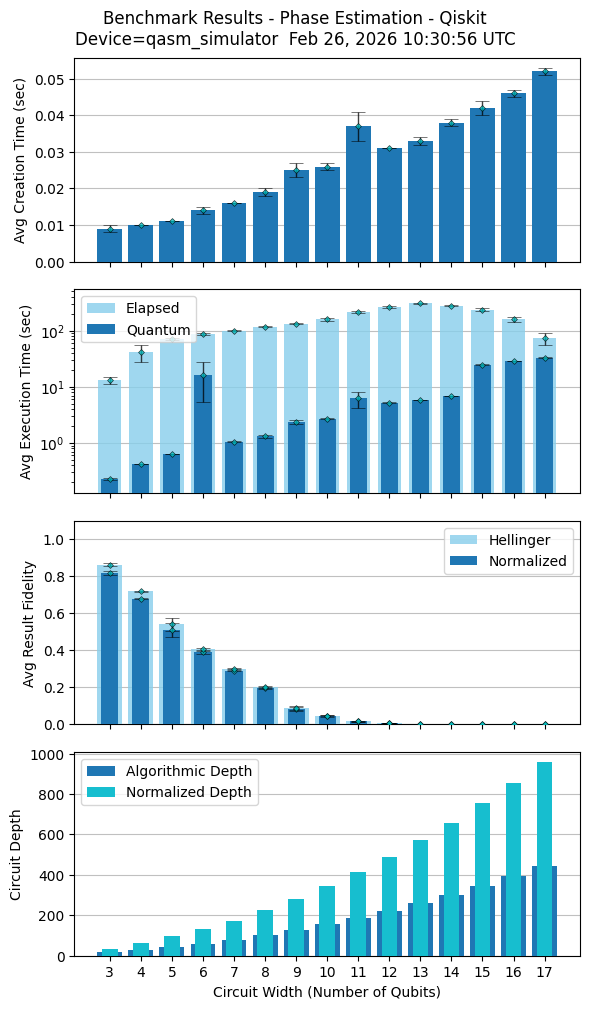

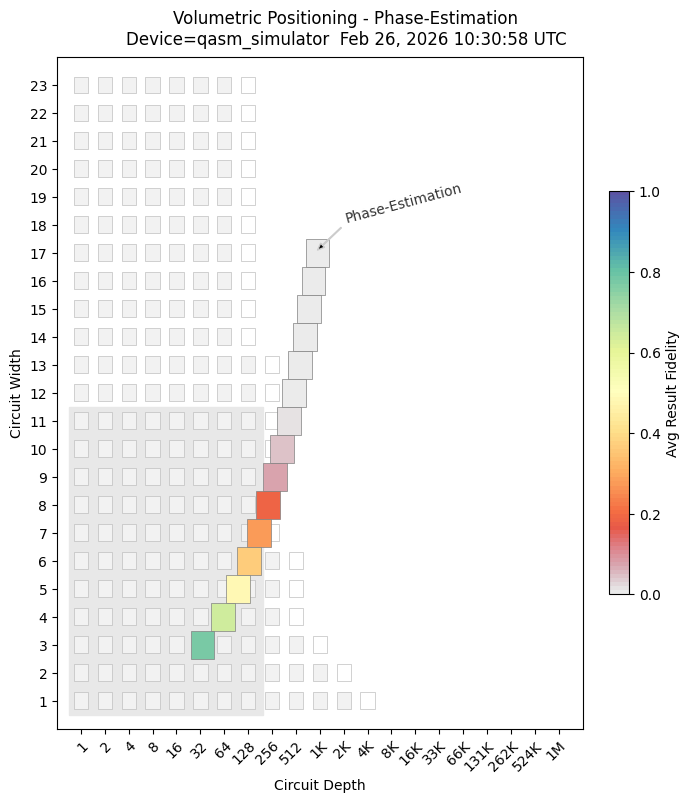

In [8]:
import sys
sys.path.insert(1, "phase-estimation")
import pe_benchmark
pe_benchmark.run(min_qubits=min_qubits, max_qubits=max_qubits, skip_qubits=skip_qubits,
                max_circuits=max_circuits, num_shots=num_shots,
                backend_id=backend_id, provider_backend=provider_backend,
                hub=hub, group=group, project=project, exec_options=exec_options)

### HHL Linear Solver

In [10]:
import sys
sys.path.insert(1, "hhl/qiskit")
import hhl_benchmark

hhl_benchmark.verbose=False

hhl_benchmark.run(min_qubits=min_qubits, max_qubits=max_qubits, skip_qubits=skip_qubits,
                max_circuits=max_circuits, num_shots=num_shots,
                method=1, use_best_widths=True,
                backend_id=backend_id, provider_backend=provider_backend,
                hub=hub, group=group, project=project, exec_options=exec_options)

HHL Benchmark Program - Qiskit
... execution starting at Feb 26, 2026 10:35:39 UTC
************
Executing 2 circuits with 4 qubits, using 1 input qubits and 1 clock qubits

@@@@@@@@@@@@@@ 
 JOB FAILED for           ┌──────────┐  ░ ┌───┐            ┌───┐   ┌───────────┐┌──────────┐»
  input: ─┤ U(π,0,π) ├──░─┤ X ├────■───────┤ X ├───┤ Rz(-3π/2) ├┤ Ry(-π/2) ├»
          └──────────┘  ░ └───┘  ┌─┴─┐   ┌─┴───┴──┐└┬──────────┤└┬────────┬┘»
 in_anc: ───────────────░────────┤ X ├───┤ Rz(-π) ├─┤ Ry(-π/2) ├─┤ Rz(-π) ├─»
         ┌────────────┐ ░        └───┘   └────────┘ └──────────┘ └────────┘ »
  clock: ┤ U(π/2,0,π) ├─░───────■───────────────────────────────────────────»
         └────────────┘ ░ ┌───┐ │P(3π/2)   ┌───┐                            »
ancilla: ───────────────░─┤ X ├─■──────────┤ X ├────────────────────────────»
                        ░ └───┘            └───┘                            »
 c126: 1/═══════════════════════════════════════════════════════════════════»
               

### Amplitude Estimation

Amplitude Estimation Benchmark Program - Qiskit
INFO: Amplitude Estimation benchmark is limited to a maximum of 8 qubits.
... execution starting at Feb 26, 2026 10:41:21 UTC
************
Executing [2] circuits with num_qubits = 3
************
Executing [2] circuits with num_qubits = 4
************
Average Circuit Algorithmic Depth, ξ (xi) for the 3 qubit group = 74, 0.391
Average Normalized Transpiled Depth, ξ (xi), 2q gates for the 3 qubit group = 106, 0.189, 25.0
Average Creation, Elapsed, Execution Time for the 3 qubit group = 0.007, 15.763, 0.613 secs
Average Hellinger, Normalized Fidelity for the 3 qubit group = 0.698, 0.396

************
Executing [2] circuits with num_qubits = 5


************
Executing [2] circuits with num_qubits = 6
************
Average Circuit Algorithmic Depth, ξ (xi) for the 4 qubit group = 214, 0.4
Average Normalized Transpiled Depth, ξ (xi), 2q gates for the 4 qubit group = 320, 0.193, 76.0
Average Creation, Elapsed, Execution Time for the 4 qubit group = 0.007, 85.374, 2.148 secs
Average Hellinger, Normalized Fidelity for the 4 qubit group = 0.428, 0.083

************
Executing [2] circuits with num_qubits = 7
************
Executing [2] circuits with num_qubits = 8
************
Average Circuit Algorithmic Depth, ξ (xi) for the 5 qubit group = 493, 0.404
Average Normalized Transpiled Depth, ξ (xi), 2q gates for the 5 qubit group = 747, 0.19, 174.0
Average Creation, Elapsed, Execution Time for the 5 qubit group = 0.009, 382.618, 5.25 secs
Average Hellinger, Normalized Fidelity for the 5 qubit group = 0.263, 0.018

************
Average Circuit Algorithmic Depth, ξ (xi) for the 6 qubit group = 1047, 0.406
Average Normalized Transpiled Depth

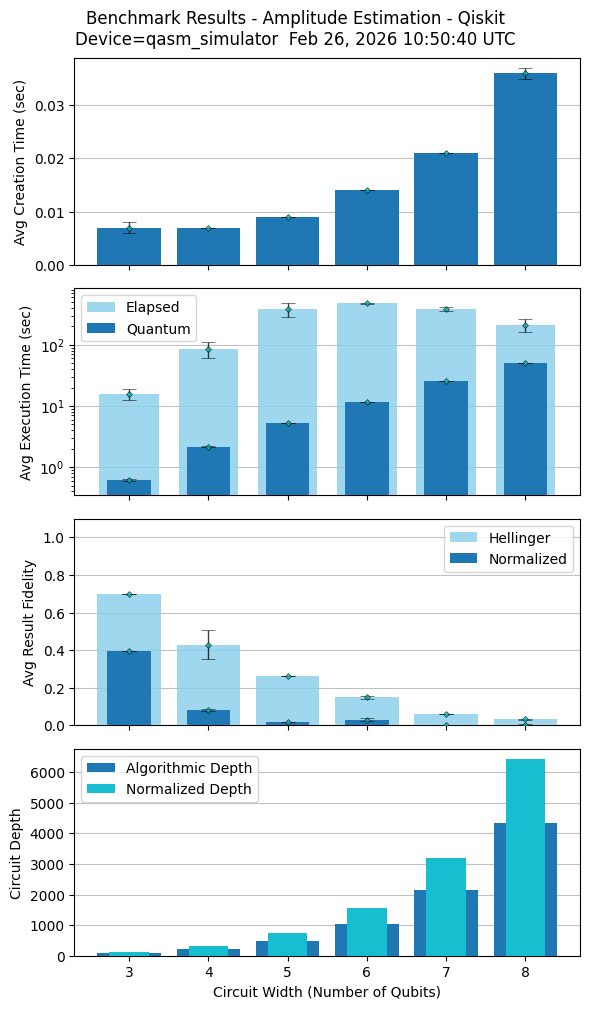

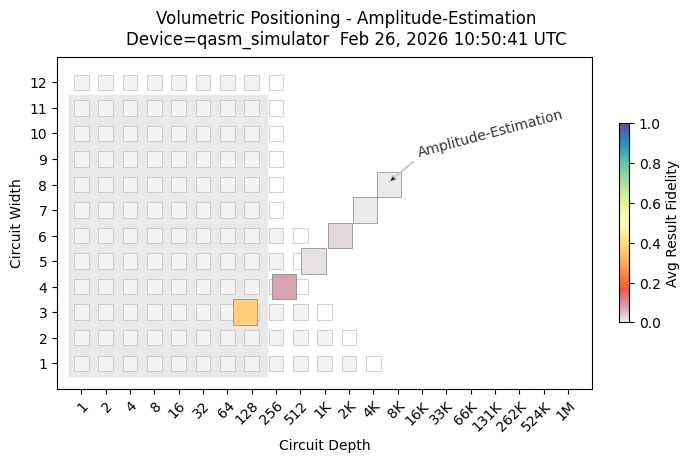

In [11]:
import sys
sys.path.insert(1, "amplitude-estimation/qiskit")


import ae_benchmark
ae_benchmark.run(min_qubits=min_qubits, max_qubits=max_qubits, skip_qubits=skip_qubits,
                max_circuits=max_circuits, num_shots=num_shots,
                backend_id=backend_id, provider_backend=provider_backend,
                hub=hub, group=group, project=project, exec_options=exec_options)



### Monte Carlo

Monte Carlo Sampling (2) Benchmark Program - Qiskit
INFO: Monte Carlo Sampling benchmark is limited to a maximum of 10 qubits.
... execution starting at Feb 26, 2026 10:50:42 UTC
************
Executing [2] circuits with num_qubits = 4
************
Executing [2] circuits with num_qubits = 5
************
Average Circuit Algorithmic Depth, ξ (xi) for the 4 qubit group = 199, 0.352
Average Normalized Transpiled Depth, ξ (xi), 2q gates for the 4 qubit group = 328, 0.206, 84.0
Average Creation, Elapsed, Execution Time for the 4 qubit group = 0.009, 36.275, 2.039 secs
Average Hellinger, Normalized Fidelity for the 4 qubit group = 0.529, 0.059

************
Executing [2] circuits with num_qubits = 6
************
Executing [2] circuits with num_qubits = 7
************
Average Circuit Algorithmic Depth, ξ (xi) for the 5 qubit group = 461, 0.354
Average Normalized Transpiled Depth, ξ (xi), 2q gates for the 5 qubit group = 755, 0.21, 196.0
Average Creation, Elapsed, Execution Time for the 5 qubit 

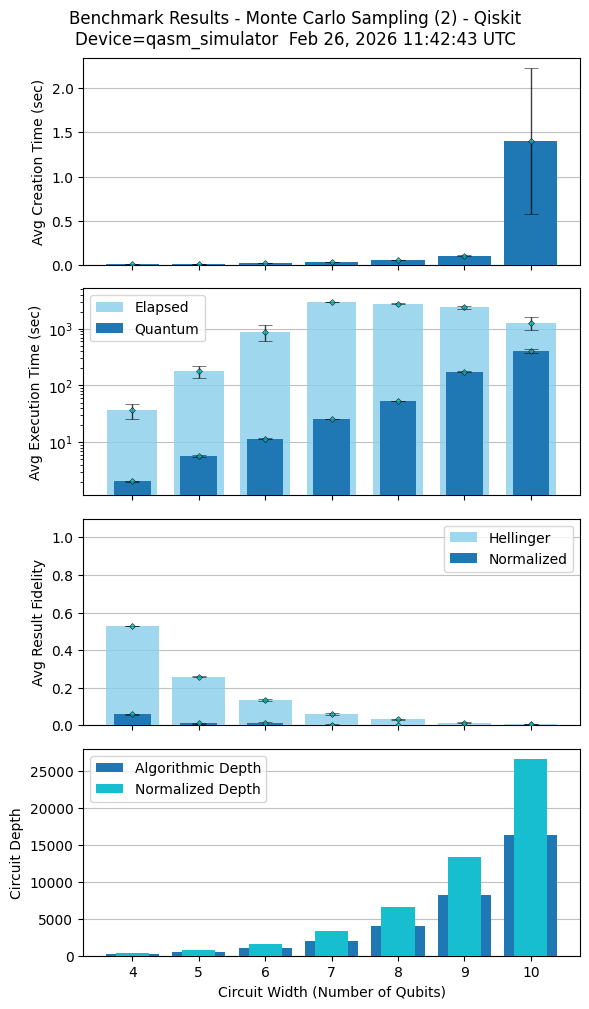

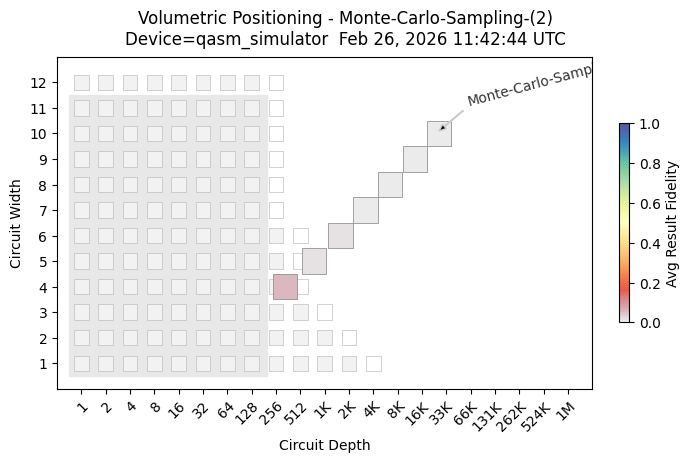

In [12]:
import sys
sys.path.insert(1, "monte-carlo/qiskit")
import mc_benchmark
mc_benchmark.run(min_qubits=min_qubits, max_qubits=max_qubits, skip_qubits=skip_qubits,
                max_circuits=max_circuits, num_shots=num_shots,
                backend_id=backend_id, provider_backend=provider_backend,
                hub=hub, group=group, project=project, exec_options=exec_options)

### Hamiltonian Simulation - Method 1 

Hamiltonian Simulation Benchmark Program - Qiskit
... execution starting at Feb 26, 2026 11:42:45 UTC
************
Executing [2] circuits with num_qubits = 2
************
Executing [2] circuits with num_qubits = 3
************
Average Circuit Algorithmic Depth, ξ (xi) for the 2 qubit group = 47, 0.246
Average Normalized Transpiled Depth, ξ (xi), 2q gates for the 2 qubit group = 91, 0.107, 15.0
Average Creation, Elapsed, Execution Time for the 2 qubit group = 0.009, 16.405, 0.683 secs
Average Hellinger, Normalized Fidelity for the 2 qubit group = 0.85, 0.699

************
Executing [2] circuits with num_qubits = 4
************
Executing [2] circuits with num_qubits = 5
************
Average Circuit Algorithmic Depth, ξ (xi) for the 3 qubit group = 72, 0.268
Average Normalized Transpiled Depth, ξ (xi), 2q gates for the 3 qubit group = 151, 0.118, 30.0
Average Creation, Elapsed, Execution Time for the 3 qubit group = 0.012, 58.026, 0.976 secs
Average Hellinger, Normalized Fidelity for the 

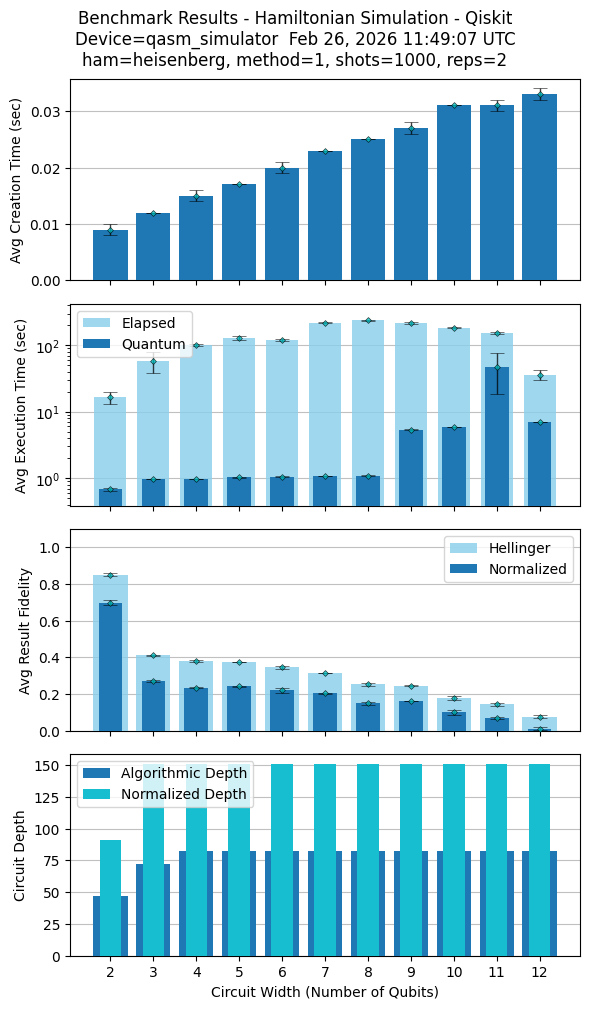

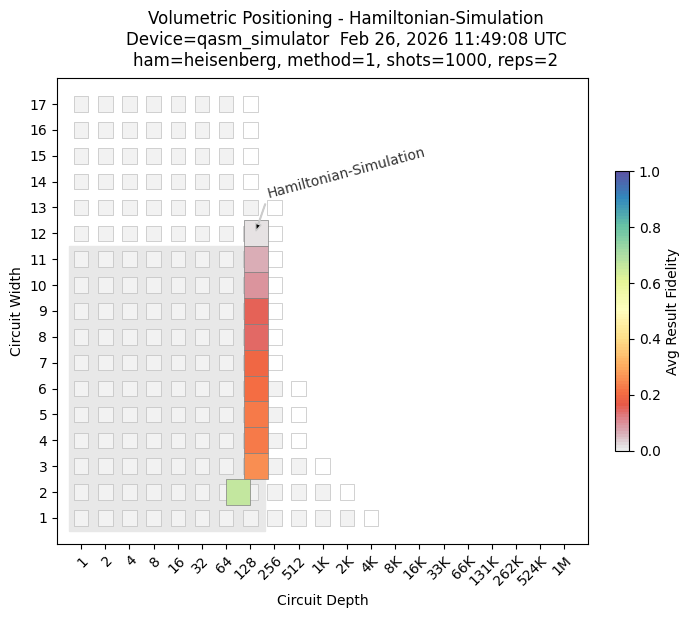

In [13]:
import sys
sys.path.insert(1, "hamiltonian-simulation/qiskit")
import hamiltonian_simulation_benchmark
hamiltonian_simulation_benchmark.run(min_qubits=min_qubits, max_qubits=max_qubits, skip_qubits=skip_qubits,
                max_circuits=max_circuits, num_shots=num_shots,
                method=1,
                backend_id=backend_id, provider_backend=provider_backend,
                hub=hub, group=group, project=project, exec_options=exec_options)

### Hamiltonian Simulation - Method 2 

Hamiltonian Simulation Benchmark Program - Qiskit
... execution starting at Feb 26, 2026 11:49:10 UTC
************
Executing [2] circuits with num_qubits = 2
************
Executing [2] circuits with num_qubits = 3
************
Average Circuit Algorithmic Depth, ξ (xi) for the 2 qubit group = 47, 0.246
Average Normalized Transpiled Depth, ξ (xi), 2q gates for the 2 qubit group = 91, 0.107, 15.0
Average Creation, Elapsed, Execution Time for the 2 qubit group = 0.008, 14.89, 0.653 secs
Average Hellinger, Normalized Fidelity for the 2 qubit group = 0.831, 0.672

************
Executing [2] circuits with num_qubits = 4
************
Executing [2] circuits with num_qubits = 5
************
Average Circuit Algorithmic Depth, ξ (xi) for the 3 qubit group = 72, 0.268
Average Normalized Transpiled Depth, ξ (xi), 2q gates for the 3 qubit group = 151, 0.118, 30.0
Average Creation, Elapsed, Execution Time for the 3 qubit group = 0.01, 30.267, 1.21 secs
Average Hellinger, Normalized Fidelity for the 3 

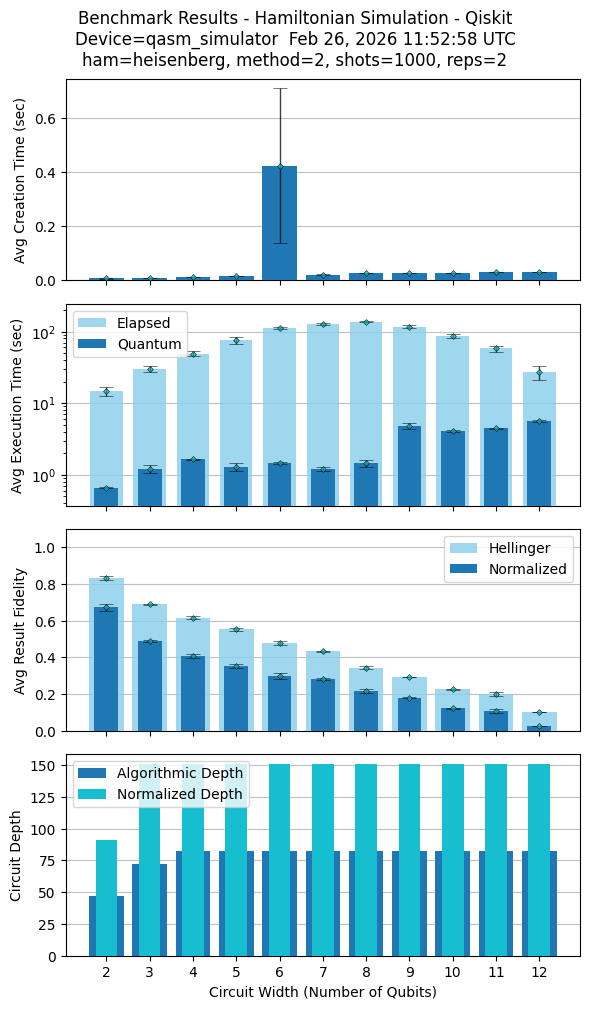

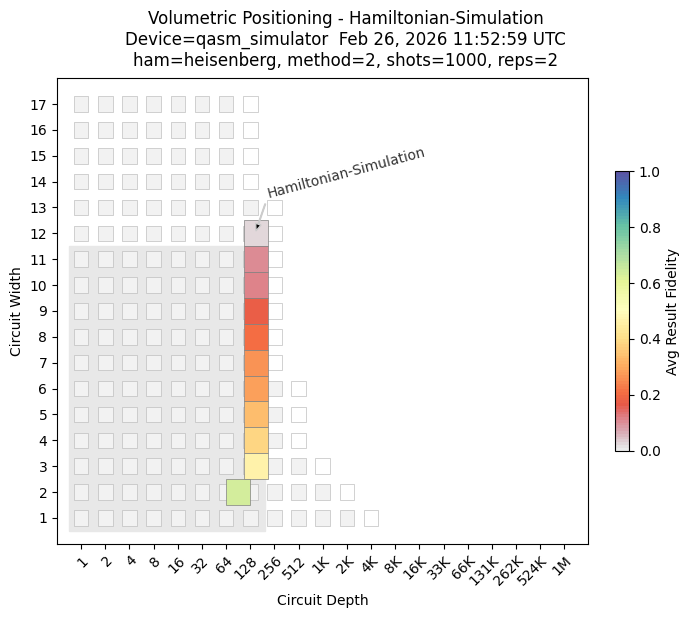

In [14]:
import sys
sys.path.insert(1, "hamiltonian-simulation/qiskit")
import hamiltonian_simulation_benchmark
hamiltonian_simulation_benchmark.run(min_qubits=min_qubits, max_qubits=max_qubits, skip_qubits=skip_qubits,
                max_circuits=max_circuits, num_shots=num_shots,
                method=2,
                backend_id=backend_id, provider_backend=provider_backend,
                hub=hub, group=group, project=project, exec_options=exec_options)

### VQE - Method 1

VQE Simulation (1) Benchmark Program - Qiskit
... execution starting at Feb 26, 2026 11:53:01 UTC
************
Executing [2] circuits with num_qubits = 4
************
Executing [2] circuits with num_qubits = 6


************
Average Circuit Algorithmic Depth, ξ (xi) for the 4 qubit group = 5, 0.0
Average Normalized Transpiled Depth, ξ (xi), 2q gates for the 4 qubit group = 178, 0.247, 56.0
Average Creation, Elapsed, Execution Time for the 4 qubit group = 3.132, 28.594, 1.312 secs
Average Hellinger, Normalized Fidelity for the 4 qubit group = 0.365, 0.215

************
Executing [2] circuits with num_qubits = 8


************
Executing [2] circuits with num_qubits = 10
************
Average Circuit Algorithmic Depth, ξ (xi) for the 6 qubit group = 10, 0.0
Average Normalized Transpiled Depth, ξ (xi), 2q gates for the 6 qubit group = 836, 0.273, 272.0
Average Creation, Elapsed, Execution Time for the 6 qubit group = 9.739, 631.062, 5.989 secs
Average Hellinger, Normalized Fidelity for the 6 qubit group = 0.054, 0.001

************
Executing [2] circuits with num_qubits = 12
************
Average Circuit Algorithmic Depth, ξ (xi) for the 8 qubit group = 26, 0.0
Average Normalized Transpiled Depth, ξ (xi), 2q gates for the 8 qubit group = 3949, 0.284, 1280.0
Average Creation, Elapsed, Execution Time for the 8 qubit group = 38.341, 3240.099, 31.831 secs
Average Hellinger, Normalized Fidelity for the 8 qubit group = 0.057, 0.003

************
Average Circuit Algorithmic Depth, ξ (xi) for the 10 qubit group = 50, 0.0
Average Normalized Transpiled Depth, ξ (xi), 2q gates for the 10 qubit group = 10396, 0

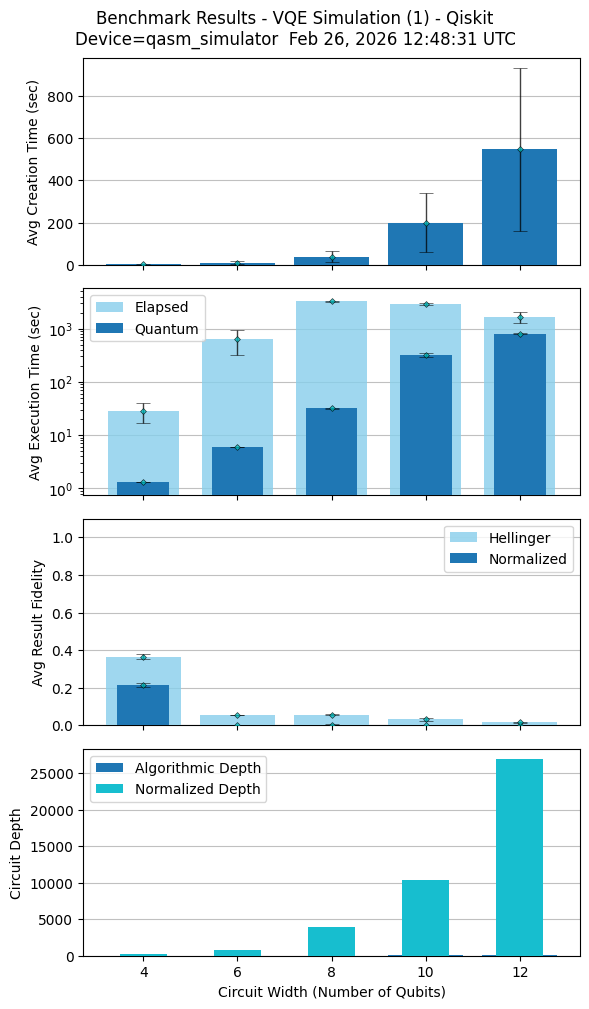

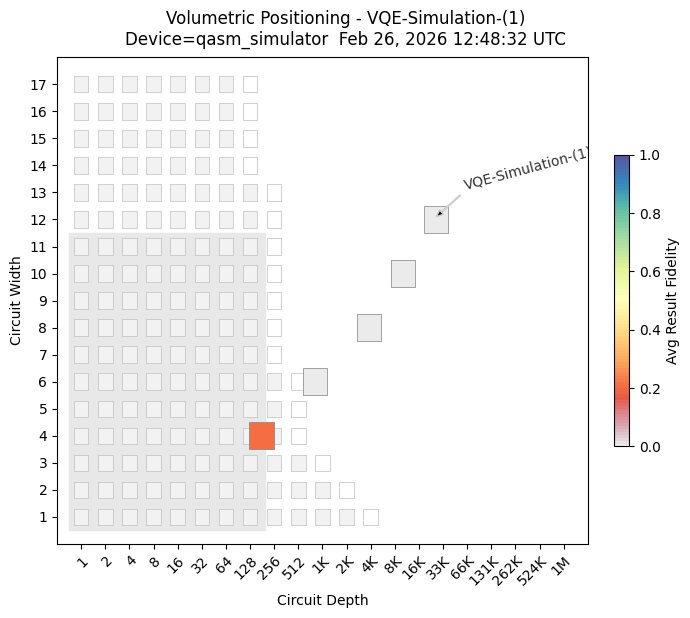

In [15]:
import sys
sys.path.insert(1, "vqe/qiskit")
import vqe_benchmark
vqe_num_shots=4098
vqe_benchmark.run(min_qubits=min_qubits, max_qubits=max_qubits,
                max_circuits=max_circuits, num_shots=vqe_num_shots,
                method=1,
                backend_id=backend_id, provider_backend=provider_backend,
                hub=hub, group=group, project=project, exec_options=exec_options)

### Shor - Method 1

Shor's Order Finding (1) Benchmark - Qiskit
... execution starting at Feb 26, 2026 12:48:33 UTC
************
Executing [1] circuits with num_qubits = 10
************
Average Circuit Algorithmic Depth, ξ (xi) for the 10 qubit group = 904, 0.536
Average Normalized Transpiled Depth, ξ (xi), 2q gates for the 10 qubit group = 4940, 0.202, 1404.0
Average Creation, Elapsed, Execution Time for the 10 qubit group = 0.203, 161.248, 59.34 secs
Average Hellinger, Normalized Fidelity for the 10 qubit group = 0.119, 0.0

************
Executing [1] circuits with num_qubits = 14
************
Average Circuit Algorithmic Depth, ξ (xi) for the 14 qubit group = 2759, 0.588
Average Normalized Transpiled Depth, ξ (xi), 2q gates for the 14 qubit group = 15150, 0.199, 4422.0
Average Creation, Elapsed, Execution Time for the 14 qubit group = 0.479, 403.03, 213.421 secs
Average Hellinger, Normalized Fidelity for the 14 qubit group = 0.027, 0.0

... execution complete at Feb 26, 2026 12:58:00 UTC in 566.112 secs

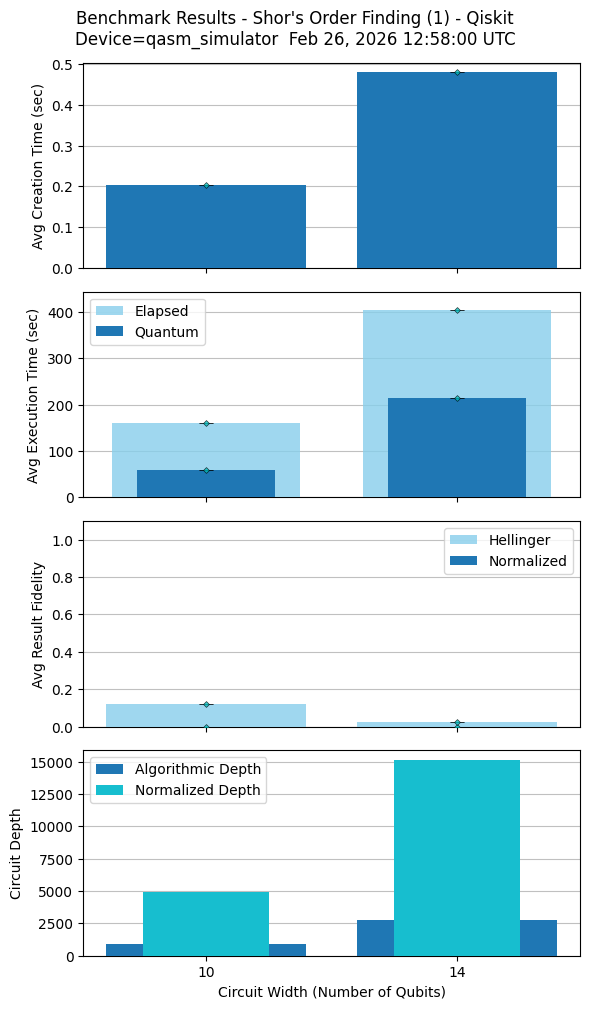

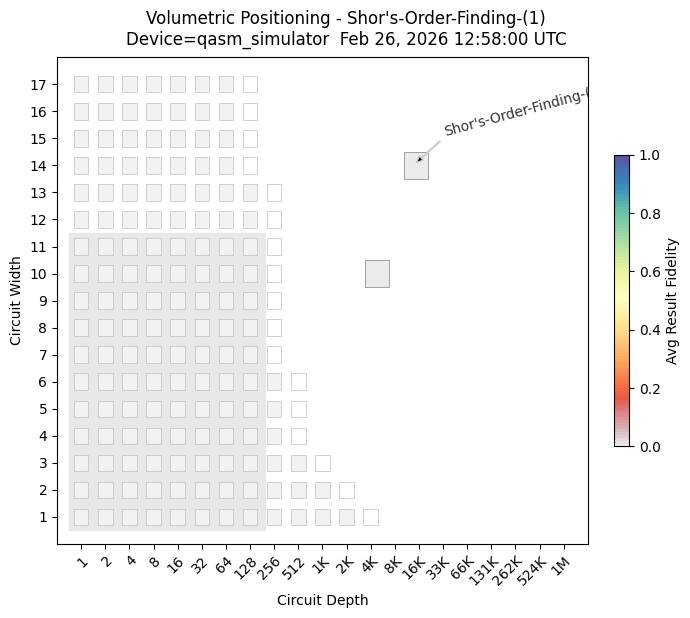

In [16]:
import sys
sys.path.insert(1, "shors/qiskit")
import shors_benchmark
shors_benchmark.run(min_qubits=min_qubits, max_qubits=max_qubits, max_circuits=1, num_shots=num_shots,
                method=1,
                backend_id=backend_id, provider_backend=provider_backend,
                hub=hub, group=group, project=project, exec_options=exec_options)

### Shor - Method 2

In [17]:
import sys
sys.path.insert(1, "shors/qiskit")
import shors_benchmark
shors_benchmark.run(min_qubits=min_qubits, max_qubits=max_qubits, max_circuits=1, num_shots=num_shots,
                method=2,
                backend_id=backend_id, provider_backend=provider_backend,
                hub=hub, group=group, project=project, exec_options=exec_options)

Shor's Order Finding (2) Benchmark - Qiskit
... execution starting at Feb 26, 2026 12:58:02 UTC
************
Executing [1] circuits with num_qubits = 7


ERROR:pyqasm: 
 >>>>>> if (c255[0] == true) {
}




ERROR: Failed to execute circuit 7 (3, 2)
... exception = Missing if block
************
Executing [1] circuits with num_qubits = 9


ERROR:pyqasm: 
 >>>>>> if (c257[0] == true) {
}




ERROR: Failed to execute circuit 9 (5, 2)
... exception = Missing if block
************
Executing [1] circuits with num_qubits = 11


...

ERROR:pyqasm: 
 >>>>>> if (c261[0] == true) {
}




ERROR: Failed to execute circuit 13 (29, 2)
... exception = Missing if block
************
Executing [1] circuits with num_qubits = 15


ERROR:pyqasm: 
 >>>>>> if (c263[0] == true) {
}




ERROR: Failed to execute circuit 15 (34, 2)
... exception = Missing if block
************
Executing [1] circuits with num_qubits = 17


ValueError: Exceeds the limit (4300 digits) for integer string conversion; use sys.set_int_max_str_digits() to increase the limit

### Quantum Fourier Transform - Method 1

Quantum Fourier Transform (1) Benchmark Program - Qiskit
... execution starting at Feb 26, 2026 13:03:34 UTC
************
Executing [2] circuits with num_qubits = 2
... number of gates, depth = 11, 8
************
Executing [2] circuits with num_qubits = 3
... number of gates, depth = 19, 14
************
Average Circuit Algorithmic Depth, ξ (xi) for the 2 qubit group = 8, 0.236
Average Normalized Transpiled Depth, ξ (xi), 2q gates for the 2 qubit group = 30, 0.116, 4.0
Average Creation, Elapsed, Execution Time for the 2 qubit group = 0.001, 13.276, 0.267 secs
Average Hellinger, Normalized Fidelity for the 2 qubit group = 0.927, 0.902

************
Executing [2] circuits with num_qubits = 4
... number of gates, depth = 30, 22
************
Executing [2] circuits with num_qubits = 5
... number of gates, depth = 42, 32
************
Average Circuit Algorithmic Depth, ξ (xi) for the 3 qubit group = 14, 0.388
Average Normalized Transpiled Depth, ξ (xi), 2q gates for the 3 qubit group = 62, 0.1

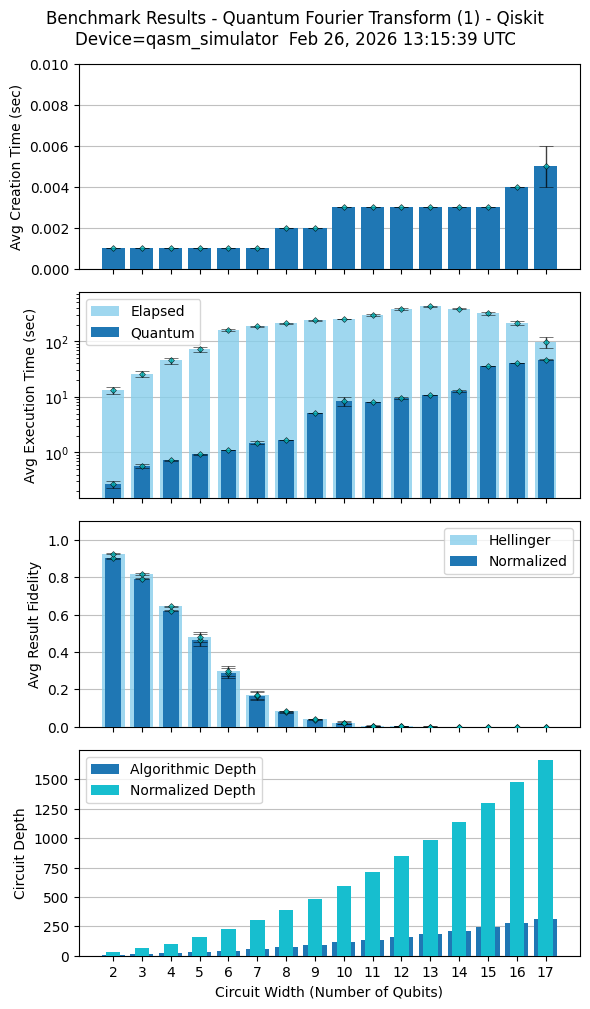

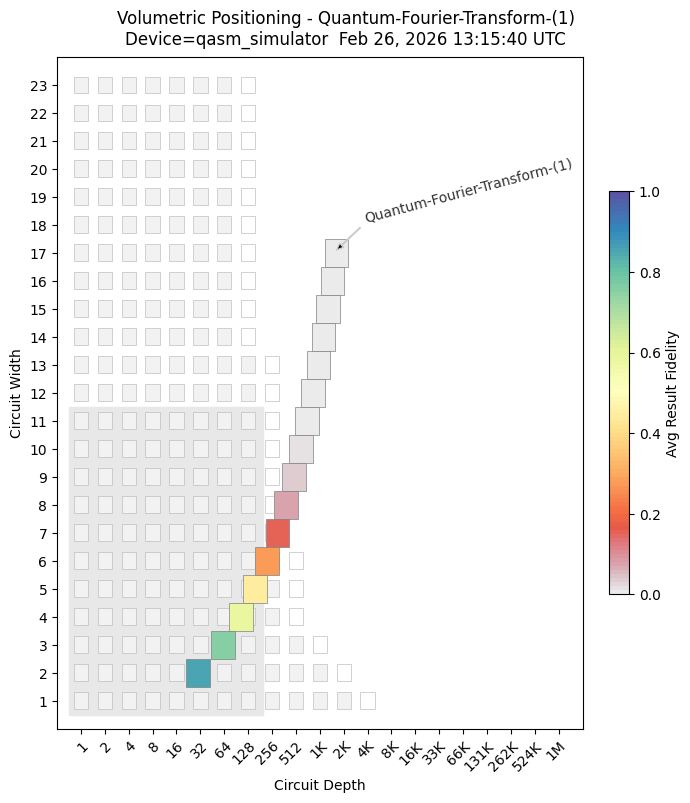

In [18]:
import sys
sys.path.insert(1, "quantum-fourier-transform")
import qft_benchmark
qft_benchmark.run(min_qubits=min_qubits, max_qubits=max_qubits, skip_qubits=skip_qubits,
                max_circuits=max_circuits, num_shots=num_shots,
                method=1,
                backend_id=backend_id, provider_backend=provider_backend,
                hub=hub, group=group, project=project, exec_options=exec_options)

### Quantum Fourier Transform - Method 2

Quantum Fourier Transform (2) Benchmark Program - Qiskit
... execution starting at Feb 26, 2026 13:15:42 UTC
************
Executing [2] circuits with num_qubits = 2
... number of gates, depth = 9, 5
************
Executing [2] circuits with num_qubits = 3
... number of gates, depth = 15, 8
************
Average Circuit Algorithmic Depth, ξ (xi) for the 2 qubit group = 6, 0.143
Average Normalized Transpiled Depth, ξ (xi), 2q gates for the 2 qubit group = 16, 0.125, 2.0
Average Creation, Elapsed, Execution Time for the 2 qubit group = 0.001, 13.083, 0.122 secs
Average Hellinger, Normalized Fidelity for the 2 qubit group = 0.958, 0.943

************
Executing [2] circuits with num_qubits = 4
... number of gates, depth = 22, 12
************
Executing [2] circuits with num_qubits = 5
... number of gates, depth = 30, 17
************
Average Circuit Algorithmic Depth, ξ (xi) for the 3 qubit group = 9, 0.25
Average Normalized Transpiled Depth, ξ (xi), 2q gates for the 3 qubit group = 33, 0.145, 

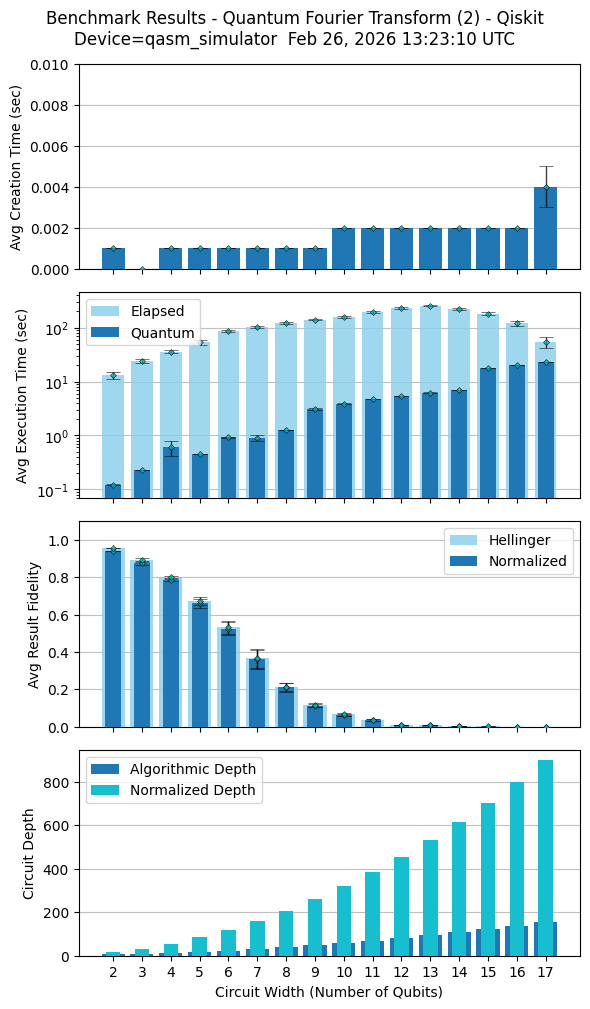

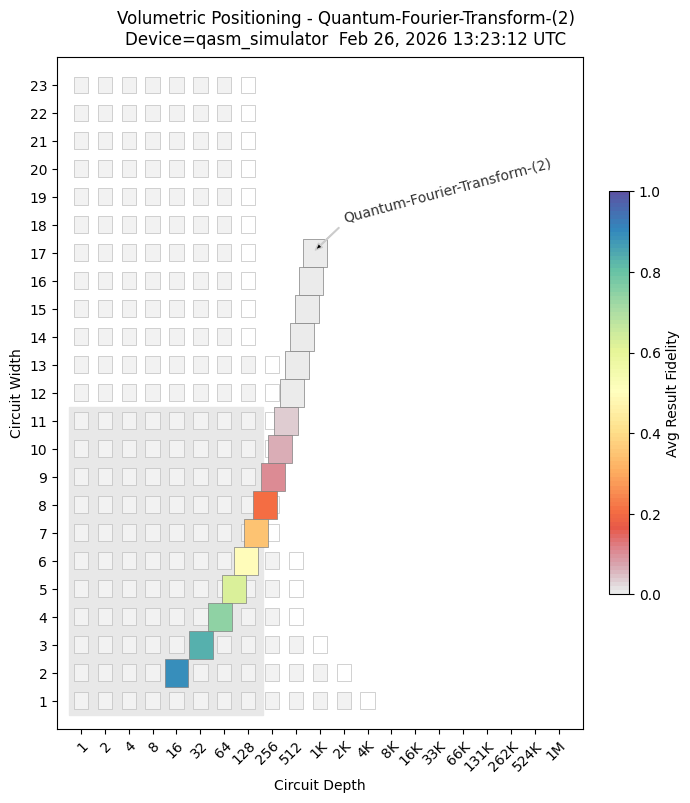

In [19]:
import sys
sys.path.insert(1, "quantum-fourier-transform")
import qft_benchmark
qft_benchmark.run(min_qubits=min_qubits, max_qubits=max_qubits, skip_qubits=skip_qubits,
                max_circuits=max_circuits, num_shots=num_shots,
                method=2,
                backend_id=backend_id, provider_backend=provider_backend,
                hub=hub, group=group, project=project, exec_options=exec_options)

### Bernstein-Vazirani - Method 2

In [20]:
import sys
sys.path.insert(1, "bernstein-vazirani")
import bv_benchmark
bv_benchmark.run(min_qubits=min_qubits, max_qubits=max_qubits, skip_qubits=skip_qubits,
                max_circuits=max_circuits, num_shots=num_shots,
                method=2,
                backend_id=backend_id, provider_backend=provider_backend,
                hub=hub, group=group, project=project, exec_options=exec_options)

Bernstein-Vazirani (2) Benchmark Program - Qiskit
... execution starting at Feb 26, 2026 13:23:13 UTC
************
Executing [2] circuits with num_qubits = 3

@@@@@@@@@@@@@@ 
 JOB FAILED for                                     ░ ┌────────────┐     ┌────────────┐┌─┐     »
q7470_0: ───────────────────────────░─┤ U(π/2,0,π) ├──■──┤ U(π/2,0,π) ├┤M├─|0>─»
         ┌──────────┐┌────────────┐ ░ └────────────┘┌─┴─┐└────────────┘└╥┘     »
q7470_1: ┤ U(π,0,π) ├┤ U(π/2,0,π) ├─░───────────────┤ X ├───────────────╫──────»
         └──────────┘└────────────┘ ░               └───┘               ║      »
 c330: 2/═══════════════════════════════════════════════════════════════╩══════»
                                                                        0      »
«         ┌─┐     
«q7470_0: ┤M├─|0>─
«         └╥┘     
«q7470_1: ─╫──────
«          ║      
« c330: 2/═╩══════
«          1       
 With error message:
 Device bell2-17-gen-preview: Unsupported operation Instruction(name='reset', num_qubit

### Close session
IMPORTANT: This cell is provided as a way to close an active session if for some reason the benchmarks abort abnormally.
If so, execute the close_session function manually to terminate an open session. Normally, this is done automatically.

In [21]:
import sys
sys.path.insert(1, "_common")
import execute as ex

ex.close_session()

****** NO RESULTS for HHL ****** 


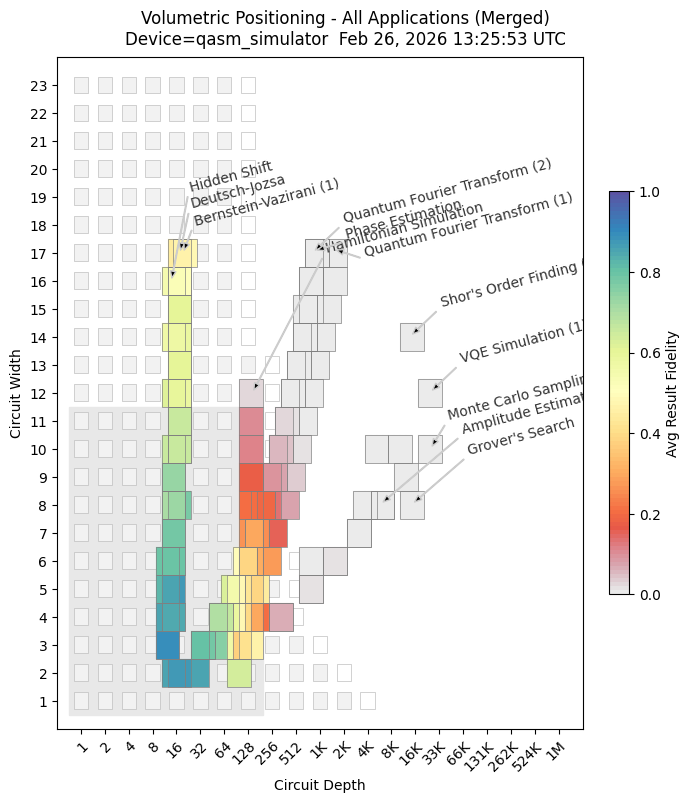

In [22]:
import sys
sys.path.insert(1, "_common")
import metrics

# metrics.depth_base = 2
# metrics.QV = 0
# apps = [ "Hidden Shift", "Grover's Search", "Quantum Fourier Transform (1)", "Hamiltonian Simulation" ]
# backend_id='qasm_simulator'

metrics.plot_all_app_metrics(backend_id, do_all_plots=False, include_apps=None)